# 02 · Logistic Regression

Logistic regression is the classification counterpart of linear regression: the same linear score $\boldsymbol{\theta}^\top\mathbf{x}$, turned into a probability.

**Contents**

1. Problem statement: why not use linear regression?
2. The sigmoid function
3. The model, log-odds and the decision boundary
4. The loss function = maximum likelihood (binary cross-entropy)
5. The gradient
6. Batch gradient descent and the learning rate
7. Convexity (and why not MSE)
8. No closed-form solution; separable data
9. Metrics for classification, with examples and graphs

Regularisation, input variables and assumptions: notebook **03**. Multiclass: notebook **04**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## 1. Problem statement

Given $m$ examples $(\mathbf{x}^{(i)}, y^{(i)})$ with $y^{(i)} \in \{0, 1\}$, learn a model that outputs the **probability** that $y=1$:

$$
h_{\boldsymbol{\theta}}(\mathbf{x}) \approx P(y = 1 \mid \mathbf{x}).
$$

and then a class, by thresholding that probability.

**Why not just fit linear regression to 0/1 labels?**
- $\boldsymbol{\theta}^\top\mathbf{x}$ is unbounded: predictions like $-0.3$ or $1.4$ are not probabilities.
- Squared error punishes points that are *correctly* classified far from the boundary (a very positive score for a $y=1$ point is "wrong" by MSE), so a few far-away points drag the boundary.

The example below shows the second problem.

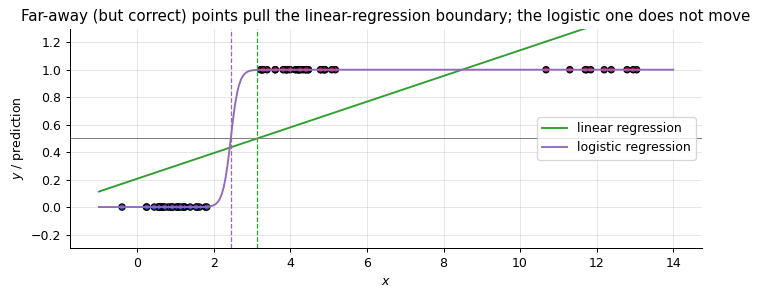

In [2]:
x1 = np.r_[rng.normal(1, 0.6, 30), rng.normal(4, 0.6, 30), rng.normal(12, 0.6, 10)]
y1 = np.r_[np.zeros(30), np.ones(40)]
X1 = np.c_[np.ones_like(x1), x1]
th_lin = np.linalg.lstsq(X1, y1, rcond=None)[0]

from sklearn.linear_model import LogisticRegression
lr1 = LogisticRegression(C=1e4).fit(x1[:, None], y1)

g = np.linspace(-1, 14, 300)
plt.figure(figsize=(8, 3.4))
plt.scatter(x1, y1, c=y1, cmap="coolwarm", edgecolor="k", s=25)
plt.plot(g, th_lin[0] + th_lin[1] * g, "C2", label="linear regression")
plt.plot(g, lr1.predict_proba(g[:, None])[:, 1], "C4", label="logistic regression")
plt.axvline((0.5 - th_lin[0]) / th_lin[1], color="C2", ls="--", lw=1)
plt.axvline(-lr1.intercept_[0] / lr1.coef_[0, 0], color="C4", ls="--", lw=1)
plt.axhline(0.5, color="gray", lw=0.8); plt.ylim(-0.3, 1.3); plt.legend(loc="center right")
plt.title("Far-away (but correct) points pull the linear-regression boundary; the logistic one does not move")
plt.xlabel("$x$"); plt.ylabel("$y$ / prediction"); plt.tight_layout(); plt.show()

## 2. The sigmoid function

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

Properties (each one is used later):

1. $\sigma(z) \in (0,1)$, $\sigma(0) = \tfrac12$, $\sigma(z)\to 1$ as $z\to\infty$, $\sigma(z)\to 0$ as $z\to-\infty$.
2. **Symmetry**: $1 - \sigma(z) = \sigma(-z)$.
   *Proof:* $1 - \frac{1}{1+e^{-z}} = \frac{e^{-z}}{1+e^{-z}} = \frac{1}{e^{z}+1} = \sigma(-z)$.
3. **Derivative**: $\sigma'(z) = \sigma(z)\big(1-\sigma(z)\big)$.
   *Proof:* $\sigma'(z) = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}}\cdot\frac{e^{-z}}{1+e^{-z}} = \sigma(z)\,(1-\sigma(z))$.
4. **Inverse** (the *logit*): if $p = \sigma(z)$ then $z = \log\frac{p}{1-p}$.
   *Proof:* $p(1+e^{-z}) = 1 \Rightarrow e^{-z} = \frac{1-p}{p} \Rightarrow z = \log\frac{p}{1-p}$.

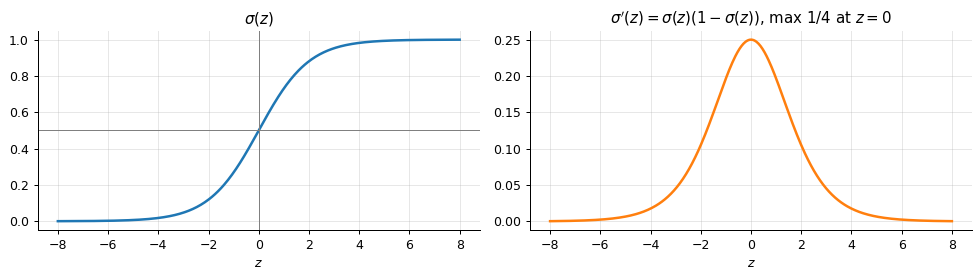

In [3]:
z = np.linspace(-8, 8, 400); s = 1 / (1 + np.exp(-z))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(z, s, lw=2); axes[0].axhline(0.5, color="gray", lw=0.8); axes[0].axvline(0, color="gray", lw=0.8)
axes[0].set_title(r"$\sigma(z)$"); axes[0].set_xlabel("$z$")
axes[1].plot(z, s * (1 - s), lw=2, color="C1"); axes[1].set_title(r"$\sigma'(z)=\sigma(z)(1-\sigma(z))$, max $1/4$ at $z=0$")
axes[1].set_xlabel("$z$"); plt.tight_layout(); plt.show()

## 3. The model, log-odds and the decision boundary

$$
h_{\boldsymbol{\theta}}(\mathbf{x}) = P(y=1\mid\mathbf{x};\boldsymbol{\theta}) = \sigma(\boldsymbol{\theta}^\top\mathbf{x}) = \frac{1}{1+e^{-\boldsymbol{\theta}^\top\mathbf{x}}}
$$

**Log-odds are linear.** By property 4, with $p = h_{\boldsymbol{\theta}}(\mathbf{x})$:

$$
\log\frac{p}{1-p} = \boldsymbol{\theta}^\top\mathbf{x} = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n .
$$

**Interpreting $\theta_j$.** Increasing $x_j$ by one unit (others fixed) adds $\theta_j$ to the log-odds, i.e. **multiplies the odds $p/(1-p)$ by $e^{\theta_j}$** (the *odds ratio*). E.g. $\theta_j = 0.7$ means the odds roughly double ($e^{0.7}\approx 2$) per unit of $x_j$. The effect on the probability itself is not constant: it is largest near $p=0.5$.

**Decision rule and boundary.** Predict $\hat{y}=1$ if $h_{\boldsymbol{\theta}}(\mathbf{x}) \ge \tau$ (threshold, default $\tau=0.5$). Since $\sigma$ is increasing and $\sigma(0)=0.5$:

$$
h_{\boldsymbol{\theta}}(\mathbf{x}) \ge 0.5 \iff \boldsymbol{\theta}^\top\mathbf{x} \ge 0 .
$$

The **decision boundary** $\{\mathbf{x} : \boldsymbol{\theta}^\top\mathbf{x} = 0\}$ is a hyperplane (a line in 2D), so logistic regression is a **linear classifier**. The sigmoid only turns the signed distance to that hyperplane into a probability. For another threshold $\tau$ the boundary is the parallel hyperplane $\boldsymbol{\theta}^\top\mathbf{x} = \log\frac{\tau}{1-\tau}$. Curved boundaries need non-linear features (notebook 03).

## 4. The loss function: maximum likelihood

Write $p^{(i)} = h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)})$. The model says $y^{(i)}$ is a **Bernoulli** variable with parameter $p^{(i)}$. Both cases $y=1$ (probability $p$) and $y=0$ (probability $1-p$) fit in one formula:

$$
P(y^{(i)} \mid \mathbf{x}^{(i)};\boldsymbol{\theta}) = \big(p^{(i)}\big)^{y^{(i)}}\big(1-p^{(i)}\big)^{1-y^{(i)}} .
$$

(Plug in $y=1$: you get $p$; plug in $y=0$: you get $1-p$.)

For independent examples the likelihood is the product, and the log-likelihood is

$$
\log L(\boldsymbol{\theta}) = \sum_{i=1}^m \Big[y^{(i)}\log p^{(i)} + (1-y^{(i)})\log\big(1-p^{(i)}\big)\Big].
$$

Maximising $\log L$ = minimising $-\frac{1}{m}\log L$. That is our loss, the **binary cross-entropy** (log-loss):

$$
\boxed{J(\boldsymbol{\theta}) = -\frac{1}{m}\sum_{i=1}^m \Big[y^{(i)}\log h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) + (1-y^{(i)})\log\big(1-h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)})\big)\Big]}
$$

So, exactly as for linear regression, **minimising $J$ is maximum likelihood**; only the noise model changed (Bernoulli instead of Gaussian).

**Intuition.** For a positive example the loss is $-\log p$: 0 if $p=1$, and $\to\infty$ as $p\to 0$. Confident mistakes are punished very hard.

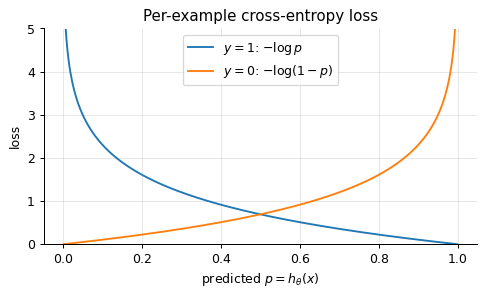

In [4]:
p = np.linspace(0.001, 0.999, 400)
plt.figure(figsize=(5.5, 3.4))
plt.plot(p, -np.log(p), label=r"$y=1$: $-\log p$")
plt.plot(p, -np.log(1 - p), label=r"$y=0$: $-\log(1-p)$")
plt.xlabel(r"predicted $p = h_\theta(x)$"); plt.ylabel("loss"); plt.ylim(0, 5); plt.legend()
plt.title("Per-example cross-entropy loss"); plt.tight_layout(); plt.show()

## 5. The gradient

Take one example and write $z = \boldsymbol{\theta}^\top\mathbf{x}$, $p=\sigma(z)$, $\ell = -[y\log p + (1-y)\log(1-p)]$. Chain rule, $\frac{\partial\ell}{\partial\theta_j} = \frac{\partial \ell}{\partial p}\cdot\frac{\partial p}{\partial z}\cdot\frac{\partial z}{\partial\theta_j}$:

$$
\frac{\partial \ell}{\partial p} = -\frac{y}{p} + \frac{1-y}{1-p}, \qquad
\frac{\partial p}{\partial z} = p(1-p), \qquad
\frac{\partial z}{\partial\theta_j} = x_j .
$$

Multiply the first two:

$$
\Big(-\frac{y}{p} + \frac{1-y}{1-p}\Big)p(1-p) = -y(1-p) + (1-y)p = p - y .
$$

So $\frac{\partial \ell}{\partial\theta_j} = (p - y)\,x_j$ and, averaging over examples,

$$
\boxed{\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \frac{1}{m}\sum_{i=1}^m\big(h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) - y^{(i)}\big)\mathbf{x}^{(i)} = \frac{1}{m}\mathbf{X}^\top\big(\sigma(\mathbf{X}\boldsymbol{\theta}) - \mathbf{y}\big)}
$$

**It is the same formula as linear regression**, "(prediction − target) × input", with $\sigma(\mathbf{X}\boldsymbol{\theta})$ in place of $\mathbf{X}\boldsymbol{\theta}$. (This is no accident: both are *generalised linear models* with their "canonical" link.)

## 6. Batch gradient descent

$$
\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \frac{\alpha}{m}\mathbf{X}^\top\big(\sigma(\mathbf{X}\boldsymbol{\theta}) - \mathbf{y}\big)
$$

Everything from notebook 01 applies: standardise features, choose $\alpha$ by watching $J$ decrease (too large → oscillation; too small → slow). A safe bound: since $\sigma' \le \tfrac14$, the Hessian (section 7) is at most $\frac{1}{4m}\mathbf{X}^\top\mathbf{X}$, so any $\alpha < 8/\lambda_{\max}(\frac1m\mathbf{X}^\top\mathbf{X})$ is stable.

theta = [-0.334 -4.702 -0.919]
sklearn (C=1e10, i.e. no penalty): [-0.332 -4.702 -0.916]


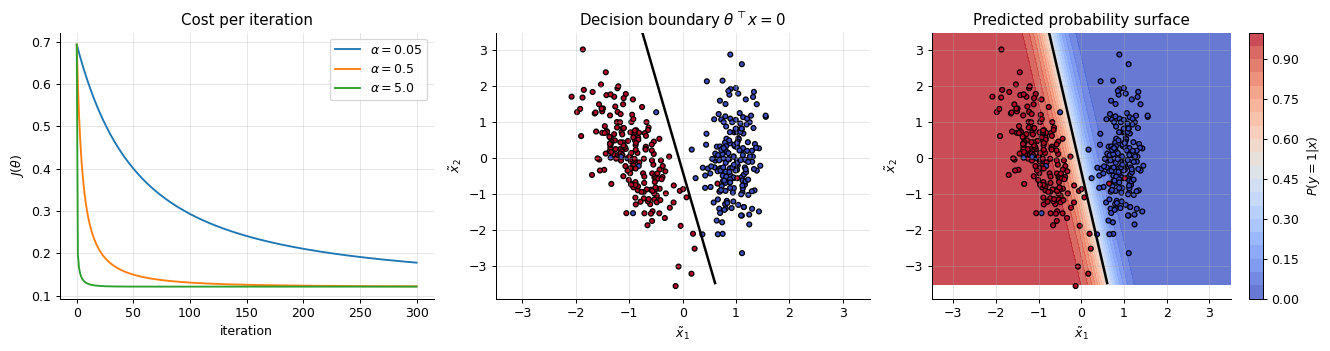

In [5]:
from sklearn.datasets import make_classification
Xr, y = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                            n_clusters_per_class=1, class_sep=1.0, flip_y=0.05, random_state=3)
mu, sd = Xr.mean(0), Xr.std(0)
X = np.c_[np.ones(len(y)), (Xr - mu) / sd]     # standardise, then add the column of ones

sigmoid = lambda z: 1 / (1 + np.exp(-z))
def J(theta, X, y, eps=1e-12):
    p = sigmoid(X @ theta)
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
def grad_J(theta, X, y):
    return X.T @ (sigmoid(X @ theta) - y) / len(y)

def gradient_descent(X, y, alpha, n_iters):
    theta = np.zeros(X.shape[1]); costs = [J(theta, X, y)]
    for _ in range(n_iters):
        theta -= alpha * grad_J(theta, X, y); costs.append(J(theta, X, y))
    return theta, costs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for a in [0.05, 0.5, 5.0]:
    th, c = gradient_descent(X, y, a, 300); axes[0].plot(c, label=rf"$\alpha={a}$")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$J(\theta)$"); axes[0].legend(); axes[0].set_title("Cost per iteration")
theta, _ = gradient_descent(X, y, 0.5, 3000)
print("theta =", theta.round(3))
sk = LogisticRegression(C=1e10).fit(X[:, 1:], y)
print("sklearn (C=1e10, i.e. no penalty):", np.r_[sk.intercept_, sk.coef_[0]].round(3))

g1, g2 = np.meshgrid(np.linspace(-3.5, 3.5, 300), np.linspace(-3.5, 3.5, 300))
P = sigmoid(theta[0] + theta[1] * g1 + theta[2] * g2)
for ax, show_p in zip(axes[1:], [False, True]):
    if show_p:
        cs = ax.contourf(g1, g2, P, levels=20, cmap="coolwarm", alpha=0.8); plt.colorbar(cs, ax=ax, label=r"$P(y=1|x)$")
    ax.scatter(X[:, 1], X[:, 2], c=y, cmap="coolwarm", edgecolor="k", s=15)
    ax.contour(g1, g2, P, levels=[0.5], colors="k", linewidths=2)
    ax.set_xlabel(r"$\tilde x_1$"); ax.set_ylabel(r"$\tilde x_2$")
axes[1].set_title(r"Decision boundary $\theta^\top x = 0$"); axes[2].set_title("Predicted probability surface")
plt.tight_layout(); plt.show()

## 7. Convexity

**Hessian.** Differentiate the gradient $\frac{1}{m}\sum_i(\sigma(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}) - y^{(i)})\mathbf{x}^{(i)}$ once more, using $\sigma' = \sigma(1-\sigma)$:

$$
\nabla^2 J(\boldsymbol{\theta}) = \frac{1}{m}\sum_{i=1}^m p^{(i)}(1-p^{(i)})\,\mathbf{x}^{(i)}\mathbf{x}^{(i)\top} = \frac{1}{m}\mathbf{X}^\top\mathbf{S}\mathbf{X}, \qquad \mathbf{S} = \mathrm{diag}\big(p^{(i)}(1-p^{(i)})\big).
$$

**PSD.** For any $\mathbf{v}$:
$$
\mathbf{v}^\top\nabla^2 J\,\mathbf{v} = \frac{1}{m}\sum_i \underbrace{p^{(i)}(1-p^{(i)})}_{>0}\,\big(\mathbf{v}^\top\mathbf{x}^{(i)}\big)^2 \;\ge 0 .
$$
So $J$ is convex: gradient descent cannot get stuck in a bad local minimum. $\blacksquare$ (It is strictly convex when the columns of $\mathbf{X}$ are linearly independent, same argument as notebook 01.)

**Why not use MSE with a sigmoid?** $\frac{1}{2m}\sum(\sigma(\boldsymbol{\theta}^\top\mathbf{x}^{(i)}) - y^{(i)})^2$ is **not convex** in $\boldsymbol{\theta}$, and its gradient contains the factor $\sigma'(z)$ which vanishes for confident wrong predictions (the model learns slowly exactly when it is most wrong). With cross-entropy, that factor cancels (section 5).

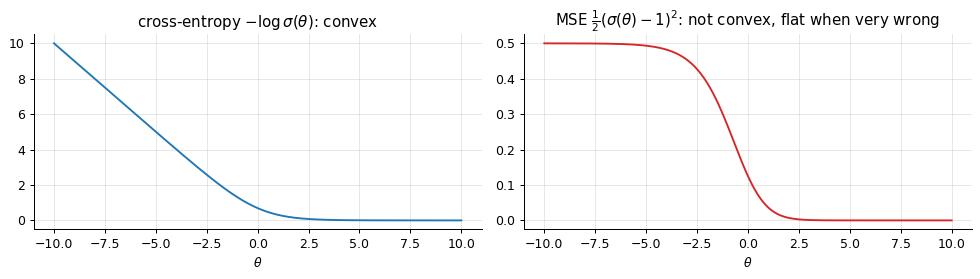

In [6]:
# One example with y=1, x=1: loss as a function of the single parameter theta
t = np.linspace(-10, 10, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(t, -np.log(sigmoid(t))); axes[0].set_title(r"cross-entropy $-\log\sigma(\theta)$: convex")
axes[1].plot(t, 0.5 * (sigmoid(t) - 1) ** 2, color="C3"); axes[1].set_title(r"MSE $\frac{1}{2}(\sigma(\theta)-1)^2$: not convex, flat when very wrong")
for ax in axes: ax.set_xlabel(r"$\theta$")
plt.tight_layout(); plt.show()

## 8. No closed form; separable data

Setting the gradient to zero gives $\mathbf{X}^\top\sigma(\mathbf{X}\boldsymbol{\theta}) = \mathbf{X}^\top\mathbf{y}$. The unknown is inside a non-linear function, so there is **no normal equation**. We use iterative methods: gradient descent, or Newton's method $\boldsymbol{\theta}\leftarrow\boldsymbol{\theta} - (\nabla^2 J)^{-1}\nabla J$ (called IRLS for this model; scikit-learn's default `lbfgs` is a quasi-Newton method).

A nice property of the optimum (take the intercept component of the equation above): $\sum_i p^{(i)} = \sum_i y^{(i)}$. **On the training set, the predicted probabilities average to the observed rate of positives.**

**Linearly separable data.** If a hyperplane separates the classes perfectly, then scaling $\boldsymbol{\theta}\to c\boldsymbol{\theta}$ with $c\to\infty$ pushes every $p^{(i)}$ towards the correct 0 or 1 and makes $J\to 0$, never reaching it. The MLE **does not exist**: GD keeps increasing $\lVert\boldsymbol{\theta}\rVert$ forever and the probabilities become overconfident. Fix: **L2 regularisation** (notebook 03), which adds $\frac{\lambda}{2m}\lVert\boldsymbol{\theta}\rVert^2$ and gives a finite solution.

## 9. Metrics for classification

A classifier outputs a score $p = h_{\boldsymbol{\theta}}(\mathbf{x})$; a threshold $\tau$ turns it into a class. Some metrics judge the **classes** (depend on $\tau$), others judge the **scores** (all thresholds at once, or the probabilities themselves).

### 9.1 Confusion matrix and threshold metrics

|  | predicted $\hat y = 0$ | predicted $\hat y = 1$ |
|---|---|---|
| **actual $y=0$** | TN (true negative) | FP (false positive, "false alarm", type I error) |
| **actual $y=1$** | FN (false negative, "miss", type II error) | TP (true positive) |

| Metric | Formula | Question it answers |
|---|---|---|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ | What fraction of all predictions is right? |
| Precision (PPV) | $\frac{TP}{TP+FP}$ | Of the ones I flagged, how many are really positive? |
| Recall / sensitivity / TPR | $\frac{TP}{TP+FN}$ | Of the real positives, how many did I catch? |
| Specificity / TNR | $\frac{TN}{TN+FP}$ | Of the real negatives, how many did I leave alone? |
| False positive rate | $\frac{FP}{FP+TN} = 1 - \text{specificity}$ | Of the real negatives, how many did I flag? |
| $F_1$ | $\frac{2\cdot\text{Prec}\cdot\text{Rec}}{\text{Prec}+\text{Rec}} = \frac{2TP}{2TP+FP+FN}$ | harmonic mean of precision and recall |

The $F_1$ score is a *harmonic* mean, so it is high only if **both** precision and recall are high (precision 1.0 with recall 0.01 gives $F_1 \approx 0.02$, not 0.5). The general $F_\beta = \frac{(1+\beta^2)\,\text{Prec}\cdot\text{Rec}}{\beta^2\text{Prec}+\text{Rec}}$ weights recall $\beta$ times as much as precision.

### Worked example: why accuracy is not enough

A fraud detector is run on 1000 insurance claims, of which **50 are fraudulent** (5 %). It flags 60 claims, 40 of which are really fraud.

- TP = 40, FP = 20, FN = 50 − 40 = 10, TN = 950 − 20 = 930.
- Accuracy = (40 + 930)/1000 = **0.97**.
- Precision = 40/60 = **0.67**: a third of the investigated claims are false alarms.
- Recall = 40/50 = **0.80**: 1 fraud in 5 goes through.
- $F_1$ = 2·40/(80 + 20 + 10) = **0.73**.

The trivial model "nothing is fraud" has accuracy **0.95**, recall **0** and undefined precision. With imbalanced classes, accuracy mostly reflects the majority class; use precision, recall, $F_1$, PR curves.

positive rate in test: 0.089


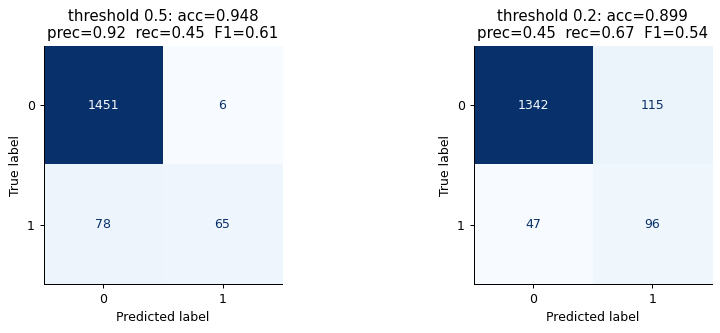

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

# An imbalanced problem: ~8% positives, 5 features
Xi, yi = make_classification(n_samples=4000, n_features=5, n_informative=3, n_redundant=0,
                             weights=[0.92], class_sep=0.9, flip_y=0.02, random_state=1)
Xtr, Xte, ytr, yte = train_test_split(Xi, yi, test_size=0.4, stratify=yi, random_state=0)
clf = LogisticRegression().fit(Xtr, ytr)
p_te = clf.predict_proba(Xte)[:, 1]
print(f"positive rate in test: {yte.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, tau in zip(axes, [0.5, 0.2]):
    yhat = (p_te >= tau).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(yte, yhat)).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"threshold {tau}: acc={accuracy_score(yte, yhat):.3f}\n"
                 f"prec={precision_score(yte, yhat):.2f}  rec={recall_score(yte, yhat):.2f}  F1={f1_score(yte, yhat):.2f}")
    ax.grid(False)
plt.tight_layout(); plt.show()

### 9.2 The threshold trade-off

Lowering $\tau$ flags more examples: recall goes up, precision (usually) goes down. $\tau = 0.5$ is only optimal if both errors cost the same. If a false negative costs $c_{FN}$ and a false positive $c_{FP}$, and probabilities are calibrated, predicting positive is worth it when $p\,c_{FN} > (1-p)\,c_{FP}$, i.e. choose

$$
\tau^* = \frac{c_{FP}}{c_{FP} + c_{FN}} .
$$

E.g. if missing a fraud costs 9× more than investigating a legitimate claim, $\tau^* = 1/10$. Choose $\tau$ on the **validation** set, never on the test set.

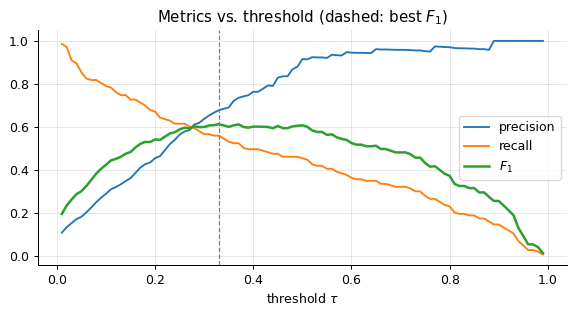

In [8]:
taus = np.linspace(0.01, 0.99, 99)
prec = [precision_score(yte, p_te >= t, zero_division=1) for t in taus]
rec = [recall_score(yte, p_te >= t) for t in taus]
f1 = [f1_score(yte, p_te >= t) for t in taus]
plt.figure(figsize=(6.5, 3.6))
plt.plot(taus, prec, label="precision"); plt.plot(taus, rec, label="recall"); plt.plot(taus, f1, label="$F_1$", lw=2)
plt.axvline(taus[int(np.argmax(f1))], color="gray", ls="--", lw=1)
plt.xlabel(r"threshold $\tau$"); plt.legend(); plt.title("Metrics vs. threshold (dashed: best $F_1$)")
plt.tight_layout(); plt.show()

### 9.3 ROC curve and AUC

The **ROC curve** plots TPR (recall) against FPR for **every** threshold $\tau$ from 1 (nothing flagged: point $(0,0)$) down to 0 (everything flagged: point $(1,1)$).
- A random classifier lies on the diagonal.
- A perfect classifier goes through $(0,1)$.

**AUC** = area under the ROC curve, between 0.5 (random) and 1 (perfect). It summarises the ranking quality over all thresholds.

**Probabilistic meaning.** AUC = probability that a randomly chosen positive gets a higher score than a randomly chosen negative:
$$
\text{AUC} = P\big(p(\mathbf{x}^+) > p(\mathbf{x}^-)\big).
$$
*Sketch of why:* sweeping $\tau$ down, each negative we pass moves the curve right by $1/N_-$, and each positive moves it up by $1/N_+$. The area added when we pass a negative is (fraction of positives already above it) $\times\, 1/N_-$. Summing over negatives gives the fraction of (positive, negative) pairs that are ranked correctly.

AUC is insensitive to the threshold and to monotone transformations of the score, and it does not change with class balance. That last property is also its weakness: with rare positives, a high AUC can hide a poor precision.

AUC (area) = 0.8788     P(score of a positive > score of a negative) = 0.8788


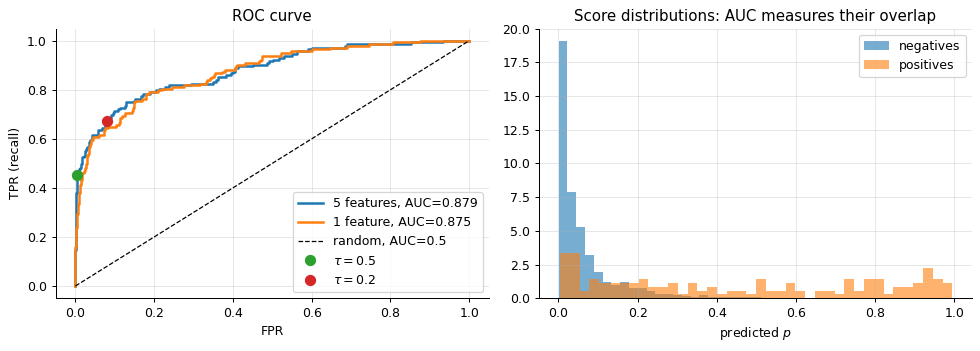

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thr = roc_curve(yte, p_te)
auc = roc_auc_score(yte, p_te)
pos, neg = p_te[yte == 1], p_te[yte == 0]
auc_pairs = np.mean(pos[:, None] > neg[None, :])
print(f"AUC (area) = {auc:.4f}     P(score of a positive > score of a negative) = {auc_pairs:.4f}")

# a weaker model: only the single most informative feature (chosen on the training set)
uni_auc = [roc_auc_score(ytr, Xtr[:, j]) for j in range(Xtr.shape[1])]
wk = [int(np.argmax(np.abs(np.array(uni_auc) - 0.5)))]
clf_weak = LogisticRegression().fit(Xtr[:, wk], ytr)
fpr_w, tpr_w, _ = roc_curve(yte, clf_weak.predict_proba(Xte[:, wk])[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, lw=2, label=f"5 features, AUC={auc:.3f}")
axes[0].plot(fpr_w, tpr_w, lw=2, label=f"1 feature, AUC={roc_auc_score(yte, clf_weak.predict_proba(Xte[:, wk])[:, 1]):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="random, AUC=0.5")
for t in [0.5, 0.2]:
    k = np.argmin(np.abs(thr - t)); axes[0].plot(fpr[k], tpr[k], "o", ms=8, label=rf"$\tau={t}$")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR (recall)"); axes[0].legend(loc="lower right"); axes[0].set_title("ROC curve")
axes[1].hist(neg, bins=40, alpha=0.6, density=True, label="negatives"); axes[1].hist(pos, bins=40, alpha=0.6, density=True, label="positives")
axes[1].set_xlabel(r"predicted $p$"); axes[1].set_title("Score distributions: AUC measures their overlap"); axes[1].legend()
plt.tight_layout(); plt.show()

### 9.4 Precision–recall curve

Plots precision against recall for every threshold. The baseline is not a diagonal but the horizontal line at the **positive rate** $\pi$ (a random classifier has precision $\pi$). It is summarised by **average precision** (AP, roughly the area under the curve). For rare positives, PR curves are more informative than ROC: at $\pi$ = 1 %, an FPR of 5 % already means far more false alarms than true positives, which the ROC curve hides but the PR curve shows.

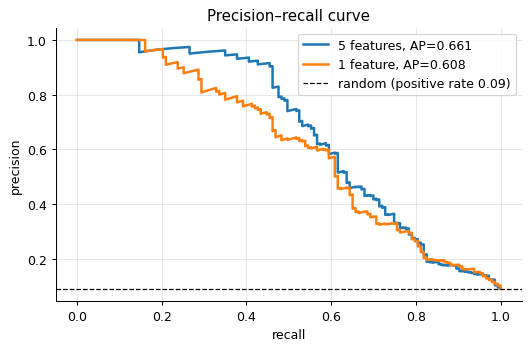

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score
pr, rc, _ = precision_recall_curve(yte, p_te)
pr_w, rc_w, _ = precision_recall_curve(yte, clf_weak.predict_proba(Xte[:, wk])[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(rc, pr, lw=2, label=f"5 features, AP={average_precision_score(yte, p_te):.3f}")
plt.plot(rc_w, pr_w, lw=2, label=f"1 feature, AP={average_precision_score(yte, clf_weak.predict_proba(Xte[:, wk])[:, 1]):.3f}")
plt.axhline(yte.mean(), color="k", ls="--", lw=1, label=f"random (positive rate {yte.mean():.2f})")
plt.xlabel("recall"); plt.ylabel("precision"); plt.legend(); plt.title("Precision–recall curve")
plt.tight_layout(); plt.show()

### 9.5 Probability metrics: log-loss, Brier score, calibration

Logistic regression gives probabilities, and often we use the numbers themselves (pricing, risk scores, expected cost). Two things to check:

- **Log-loss** (= $J$ on the test set) and **Brier score** $\frac{1}{m}\sum(p^{(i)} - y^{(i)})^2$. Lower is better; both reward probabilities that are both sharp and correct.
- **Calibration**: among all examples with predicted $p\approx 0.3$, about 30 % should be positive. A **reliability diagram** bins the predictions and plots the observed positive rate per bin against the mean prediction; a calibrated model lies on the diagonal. Logistic regression (MLE) tends to be well calibrated; SVMs, trees and heavily regularised models often are not. In the example below the over-regularised model has almost the same AUC (the *ranking* barely changes) but its probabilities are squeezed towards the base rate: AUC does not see calibration.

logistic (MLE)          : log-loss=0.185  Brier=0.0483  AUC=0.879
logistic, over-regular. : log-loss=0.286  Brier=0.0786  AUC=0.867


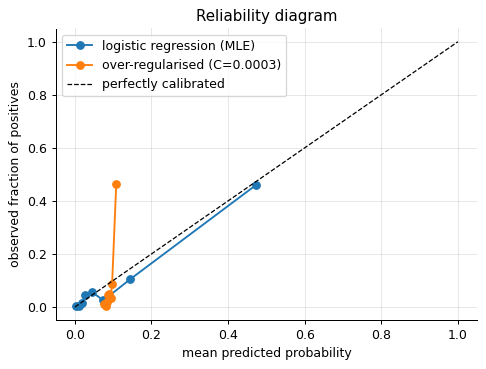

In [11]:
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
clf_reg = LogisticRegression(C=0.0003).fit(Xtr, ytr)   # far too much regularisation
p_reg = clf_reg.predict_proba(Xte)[:, 1]
print(f"logistic (MLE)          : log-loss={log_loss(yte, p_te):.3f}  Brier={brier_score_loss(yte, p_te):.4f}  AUC={roc_auc_score(yte, p_te):.3f}")
print(f"logistic, over-regular. : log-loss={log_loss(yte, p_reg):.3f}  Brier={brier_score_loss(yte, p_reg):.4f}  AUC={roc_auc_score(yte, p_reg):.3f}")

plt.figure(figsize=(5.5, 4.2))
for pp, name in [(p_te, "logistic regression (MLE)"), (p_reg, "over-regularised (C=0.0003)")]:
    frac, meanp = calibration_curve(yte, pp, n_bins=8, strategy="quantile")
    plt.plot(meanp, frac, "o-", label=name)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
plt.xlabel("mean predicted probability"); plt.ylabel("observed fraction of positives"); plt.legend()
plt.title("Reliability diagram"); plt.tight_layout(); plt.show()

### 9.6 Which metric?

| Situation | Use |
|---|---|
| Balanced classes, equal error costs | accuracy (plus the confusion matrix) |
| Rare positives, care about the positives | precision, recall, $F_1$, PR curve / AP |
| Compare rankers independent of the threshold | ROC AUC |
| The probability itself is used | log-loss, Brier score, reliability diagram |
| Known error costs | expected cost, with $\tau^* = c_{FP}/(c_{FP}+c_{FN})$ |

## Summary

- Model: $P(y=1\mid\mathbf{x}) = \sigma(\boldsymbol{\theta}^\top\mathbf{x})$; log-odds are linear; boundary $\boldsymbol{\theta}^\top\mathbf{x}=0$ is a hyperplane.
- Loss: binary cross-entropy = negative Bernoulli log-likelihood (MLE).
- Gradient: $\frac1m\mathbf{X}^\top(\sigma(\mathbf{X}\boldsymbol{\theta})-\mathbf{y})$, same form as linear regression.
- Convex (Hessian $\frac1m\mathbf{X}^\top\mathbf{S}\mathbf{X}\succeq 0$), no closed form, diverges on separable data without regularisation.
- Evaluate with the confusion matrix and threshold metrics, ROC/AUC, PR curve and calibration, picking the metric that matches the cost of each error.